# SWG — Rectified Transport with **Open Boundaries** (Desal Analogue)

## Abstract
A zero-mean **two-tone** drive acting on an **asymmetric medium** $g(x)$, coupled to a
**memory field** $\chi(x,t)$, pumps material between equal reservoirs (**open boundaries**).
We measure **throughput** as the cycle-average current crossing a fixed **mid-plane**
and show a **hysteresis loop** in $\langle J \rangle$ vs. $\eta$. Stability is verified by the
**geometry floor** (dynamic floor, 5th-percentile FVR).

---

## 1 • Model
Fields on a 1D interval $x \in [0,L]$ with **Dirichlet reservoirs** at $x=0,L$:

$$
\begin{aligned}
\partial_t A &= D_A\,\partial_{xx}A
              - \lambda\,A\,(1-A^2)
              + \eta(t)\,\partial_x\!\big[g(x)\,\chi A\big], \\
\partial_t \chi &= D_\chi\,\partial_{xx}\chi
              + \gamma_\chi\,(A^2-\chi).
\end{aligned}
$$

Conservative current:
$$
J(x,t) \;=\; -D_A\,\partial_x A \;+\; \eta(t)\,g(x)\,\chi(x,t)\,A(x,t).
$$

**Throughput metric:** fix a mid-plane $x^* = L/2$.  
Per cycle, compute $\langle J \rangle = \frac{1}{T}\int_0^T J(x^*,t)\,dt$.


In [2]:
# ============================================================
# 0) Imports, grid, parameters
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

nx, L = 1000, 20.0
x  = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Drive
freq = 0.5                   # base frequency
steps_per_cycle = 1200
cycles_relax, cycles_meas = 30, 20
dt_cycle = 1.0 / freq
dt = dt_cycle / steps_per_cycle

# PDE/medium parameters
DA   = 0.03
lam  = 0.06
Dchi = 0.02
gchi = 0.18                  # memory relaxation (lag τ≈5.6 cycles)

# Reservoirs (equal baselines)
A_left, A_right = 0.60, 0.60
chi_left, chi_right = A_left**2, A_right**2

# Sweep of drive amplitude
eta_min, eta_max, n_eta = 0.00, 0.60, 13

# Mid-plane index for throughput measurement
i_mid = nx // 2


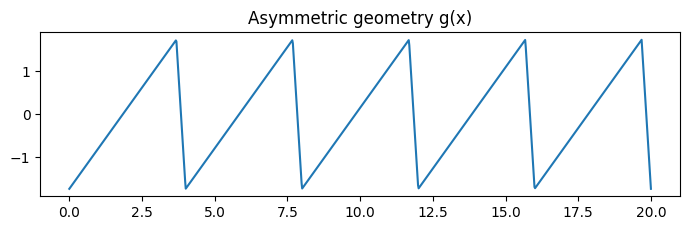

In [3]:
# ============================================================
# 1) Asymmetric geometry g(x)
# ============================================================
def saw_asym(phase, up=0.92):
    return np.where(phase < up, phase/up, 1 - (phase - up)/(1 - up))

period = L/5
phase = (x % period) / period
g = saw_asym(phase, up=0.92)
g = 2*(g - g.mean())
g = (g - g.mean()) / (np.std(g) + 1e-12)

plt.figure(figsize=(7,2.4))
plt.plot(x, g)
plt.title("Asymmetric geometry g(x)")
plt.tight_layout(); plt.show()


In [4]:
# ============================================================
# 2) Numerical ops with OPEN boundaries (Dirichlet)
# ============================================================
def apply_dirichlet(A, chi):
    A[0],   A[-1]   = A_left,  A_right
    chi[0], chi[-1] = chi_left, chi_right

def d_dx_open(f):
    df = np.empty_like(f)
    # central interior
    df[1:-1] = (f[2:] - f[:-2]) / (2*dx)
    # one-sided at boundaries (consistent with Dirichlet clamps)
    df[0]  = (f[1]  - f[0])  / dx
    df[-1] = (f[-1] - f[-2]) / dx
    return df

def lap_open(f):
    lap = np.empty_like(f)
    lap[1:-1] = (f[2:] - 2*f[1:-1] + f[:-2]) / dx**2
    # second-order one-sided at boundaries (Dirichlet held constant)
    lap[0]  = (f[2]  - 2*f[1]  + f[0])  / dx**2
    lap[-1] = (f[-1] - 2*f[-2] + f[-3]) / dx**2
    return lap

def drive_eta(t, eta):
    # Two-tone (break time-reversal): f and 2f with phase offset
    phi = 0.9*np.pi
    return eta*np.sin(2*np.pi*freq*t) + 0.6*eta*np.sin(4*np.pi*freq*t + phi)

def J_current(A, chi, eta_t):
    return -DA * d_dx_open(A) + eta_t * (g * (chi * A))


In [5]:
# ============================================================
# 3) Geometry floor (dynamic only) and FVR
# ============================================================
def geometry_floor_dynamic(A, p_metric=5):
    dA = d_dx_open(A)
    L_dyn = A / (np.abs(dA) + 1e-12)
    # light smoothing for percentile robustness
    ker = np.ones(7)/7
    L_dyn_s = np.convolve(L_dyn, ker, mode='same')
    L_floor = float(np.percentile(L_dyn_s, p_metric))
    FVR = float(np.mean(L_dyn_s < L_floor))
    return L_dyn_s, L_floor, FVR


In [6]:
# ============================================================
# 4) Integrate one cycle, measure mid-plane throughput
# ============================================================
def evolve_cycle(A, chi, eta_amp, warm=False):
    J_mid_samples = []
    for k in range(steps_per_cycle):
        t = k*dt
        eta_t = drive_eta(t, eta_amp)

        # RHS with open-boundary operators
        adv   = d_dx_open(g * (chi * A))
        dA    = DA*lap_open(A) - lam*A*(1 - np.clip(A,0,2)**2) + eta_t * adv
        dchi  = Dchi*lap_open(chi) + gchi*(np.clip(A,0,2)**2 - chi)

        # update
        A   = np.clip(A   + dt*dA,   0, 2)
        chi = np.clip(chi + dt*dchi, 0, 2)

        # enforce reservoirs
        apply_dirichlet(A, chi)

        # measure mid-plane current after early intra-cycle transient
        if not warm and k > steps_per_cycle//8:
            J = J_current(A, chi, eta_t)
            J_mid_samples.append(J[i_mid])

    J_cycle = 0.0 if warm or len(J_mid_samples)==0 else float(np.mean(J_mid_samples))
    return A, chi, J_cycle


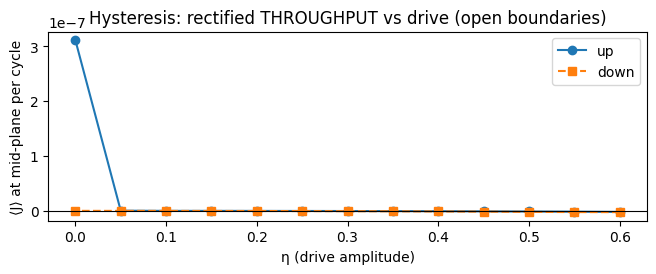

Loop area (rectification strength): 8.015e-09


In [7]:
# ============================================================
# 5) Hysteresis sweep (η up & down) — THROUGHPUT
# ============================================================
rng = np.random.default_rng(1)
A0   = A_left + 0.02*rng.standard_normal(nx)
chi0 = (np.clip(A0,0,2))**2
apply_dirichlet(A0, chi0)

etas_up   = np.linspace(eta_min, eta_max, n_eta)
etas_down = etas_up[::-1]

J_up, J_dn = [], []

A, chi = A0.copy(), chi0.copy()
for eta in etas_up:
    for _ in range(cycles_relax):
        A, chi, _ = evolve_cycle(A, chi, eta, warm=True)
    vals = []
    for _ in range(cycles_meas):
        A, chi, Jc = evolve_cycle(A, chi, eta, warm=False)
        vals.append(Jc)
    J_up.append(np.mean(vals))

for eta in etas_down:
    for _ in range(cycles_relax):
        A, chi, _ = evolve_cycle(A, chi, eta, warm=True)
    vals = []
    for _ in range(cycles_meas):
        A, chi, Jc = evolve_cycle(A, chi, eta, warm=False)
        vals.append(Jc)
    J_dn.append(np.mean(vals))

plt.figure(figsize=(6.8,3.0))
plt.plot(etas_up,   J_up, 'o-', label='up')
plt.plot(etas_down, J_dn, 's--', label='down')
plt.axhline(0, color='k', lw=0.8)
plt.xlabel("η (drive amplitude)")
plt.ylabel("⟨J⟩ at mid-plane per cycle")
plt.title("Hysteresis: rectified THROUGHPUT vs drive (open boundaries)")
plt.legend(); plt.tight_layout(); plt.show()

# loop area as rectification strength
loop_area = np.trapezoid(J_up, etas_up) - np.trapezoid(J_dn[::-1], etas_up)
print(f"Loop area (rectification strength): {loop_area:.3e}")


η*=0.450  ⟨J⟩(mid)=8.2416e-07  FVR=0.050


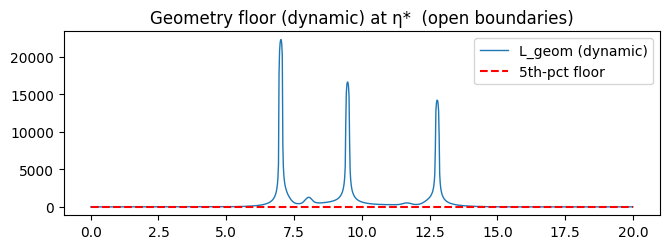

In [8]:
# ============================================================
# 6) Stability at representative η*
# ============================================================
eta_star = 0.45
A_chk, chi_chk = A0.copy(), chi0.copy()
for _ in range(max(12, cycles_relax)):
    A_chk, chi_chk, _ = evolve_cycle(A_chk, chi_chk, eta_star, warm=True)

vals = []
for _ in range(6):
    A_chk, chi_chk, Jc = evolve_cycle(A_chk, chi_chk, eta_star, warm=False)
    vals.append(Jc)

Lg, L_floor, FVR = geometry_floor_dynamic(A_chk, p_metric=5)
print(f"η*={eta_star:.3f}  ⟨J⟩(mid)={np.mean(vals):.4e}  FVR={FVR:.3f}")

plt.figure(figsize=(6.8,2.6))
plt.plot(x, Lg, lw=1.0, label='L_geom (dynamic)')
plt.hlines(L_floor, x[0], x[-1], colors='r', linestyles='--', label='5th-pct floor')
plt.title("Geometry floor (dynamic) at η*  (open boundaries)")
plt.legend(); plt.tight_layout(); plt.show()


---

## 2 • What to expect

- With **open boundaries**, the mid-plane current does **not** cancel by symmetry.  
- The combination of **asymmetric $g(x)$**, **χ-lag** ($\tau \approx 1/\gamma_\chi$), and **two-tone drive** produces a **non-zero DC throughput** and a **hysteresis loop**.  
- **Stability:** keep **FVR ≤ 0.05** across operating $\eta$; if it rises, increase $D_A$ slightly or reduce $\eta_{\max}$.

**Tips.**  
To flip the direction of pumping, invert $g \rightarrow -g$ or change the phase offset in `drive_eta`.  
For sharper loops, increase `cycles_relax` and `cycles_meas` (more steady-state averaging).
